In [100]:
import numpy as np
import pandas as pd 
import matplotlib as plt 
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

# For the WGS data 

# For the somatic mutations 

In [101]:
df_somatic_mutations = pd.read_csv("./project_data/catalogs/WGS/WGS_PCAWG.96.csv")
df_somatic_mutations = df_somatic_mutations.set_index (df_somatic_mutations['Mutation type'] + "_" + df_somatic_mutations['Trinucleotide'])

df_somatic_mutations.head()

,Mutation type,Trinucleotide,Biliary-AdenoCA::SP117655,Biliary-AdenoCA::SP117556,Biliary-AdenoCA::SP117627,Biliary-AdenoCA::SP117775,Biliary-AdenoCA::SP117332,Biliary-AdenoCA::SP117712,Biliary-AdenoCA::SP117017,Biliary-AdenoCA::SP117031,...,Uterus-AdenoCA::SP94540,Uterus-AdenoCA::SP95222,Uterus-AdenoCA::SP89389,Uterus-AdenoCA::SP90503,Uterus-AdenoCA::SP92460,Uterus-AdenoCA::SP92931,Uterus-AdenoCA::SP91265,Uterus-AdenoCA::SP89909,Uterus-AdenoCA::SP90629,Uterus-AdenoCA::SP95550
C>A_ACA,C>A,ACA,269,114,105,217,52,192,54,196,...,117,233,94,114,257,139,404,97,250,170
C>A_ACC,C>A,ACC,148,56,71,123,36,139,54,102,...,90,167,59,64,268,75,255,78,188,137
C>A_ACG,C>A,ACG,25,13,13,29,8,31,12,15,...,12,29,14,19,51,13,52,14,49,32
C>A_ACT,C>A,ACT,154,70,73,126,31,119,41,122,...,82,213,66,68,271,68,281,80,202,116
C>A_CCA,C>A,CCA,215,63,71,129,30,190,54,133,...,119,188,67,89,307,69,339,204,194,127


In [102]:
df_somatic_mutations.shape

(96, 2782)

In [103]:
cancer_types_1 = np.array([ s.split(":")[0].split("-")[1] for s in df_somatic_mutations.columns[2:] ])
cancer_types_1

array(['AdenoCA', 'AdenoCA', 'AdenoCA', ..., 'AdenoCA', 'AdenoCA',
       'AdenoCA'], shape=(2780,), dtype='<U9')

In [104]:
pd.unique(cancer_types_1)

array(['AdenoCA', 'TCC', 'Benign', 'Epith', 'Osteosarc', 'DCIS',
       'LobularCA', 'GBM', 'Medullo', 'Oligo', 'PiloAstro', 'SCC',
       'ChRCC', 'RCC', 'HCC', 'BNHL', 'CLL', 'AML', 'MDS', 'MPN',
       'Endocrine', 'Melanoma', 'Leiomyo', 'Liposarc'], dtype='<U9')

In [105]:
X_train, X_test, y_train, y_test = train_test_split(df_somatic_mutations.iloc[:, 2:].T, cancer_types_1, stratify=cancer_types_1)

In [106]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20047
[LightGBM] [Info] Number of data points in the train set: 2085, number of used features: 96
[LightGBM] [Info] Start training from score -5.563083
[LightGBM] [Info] Start training from score -0.803048
[LightGBM] [Info] Start training from score -3.260497
[LightGBM] [Info] Start training from score -5.157617
[LightGBM] [Info] Start training from score -3.379844
[LightGBM] [Info] Start training from score -4.116164
[LightGBM] [Info] Start training from score -6.949377
[LightGBM] [Info] Start training from score -3.483641
[LightGBM] [Info] Start training from score -5.563083
[LightGBM] [Info] Start training from score -4.208537
[LightGBM] [Info] Start training from score -2.141266
[LightGBM] [Info] Start training from score -5.244629
[LightGBM] [Info] Start training from score -5.003467
[LightGBM

In [107]:
print(models)

                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
LGBMClassifier                     0.84               0.49    None      0.82   
RandomForestClassifier             0.81               0.46    None      0.79   
ExtraTreesClassifier               0.79               0.42    None      0.75   
KNeighborsClassifier               0.77               0.39    None      0.74   
BaggingClassifier                  0.76               0.38    None      0.74   
LinearSVC                          0.77               0.36    None      0.73   
DecisionTreeClassifier             0.66               0.35    None      0.66   
ExtraTreeClassifier                0.59               0.32    None      0.58   
GaussianNB                         0.28               0.32    None      0.29   
LabelPropagation                   0.70               0.31    None      0.66   
PassiveAggressiveClassifier        0.65 

# For Activities

In [108]:
df_activities = pd.read_csv("./project_data/activities/WGS/WGS_PCAWG.activities.csv")
df_activities.head()

,Cancer Types,Sample Names,Accuracy,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,Biliary-AdenoCA,SP117655,0.97,1496,1296,0,0,1825,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Biliary-AdenoCA,SP117556,0.96,985,0,0,0,922,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Biliary-AdenoCA,SP117627,0.97,1110,528,0,0,1453,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Biliary-AdenoCA,SP117775,0.99,1803,1271,0,0,2199,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Biliary-AdenoCA,SP117332,0.99,441,461,0,0,840,0,0,...,0,0,0,0,0,0,0,0,0,0


In [109]:
#drop sample names and accuracy columns as they do not give any valuable information 
df_activities.drop(columns=["Sample Names", "Accuracy"], inplace=True)
df_activities.head()

,Cancer Types,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,SBS7b,SBS7c,...,SBS51,SBS52,SBS53,SBS54,SBS55,SBS56,SBS57,SBS58,SBS59,SBS60
0,Biliary-AdenoCA,1496,1296,0,0,1825,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Biliary-AdenoCA,985,0,0,0,922,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Biliary-AdenoCA,1110,528,0,0,1453,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Biliary-AdenoCA,1803,1271,0,0,2199,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Biliary-AdenoCA,441,461,0,0,840,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [110]:
cancer_types_2 = np.array([ s.split(":")[0].split("-")[1] for s in df_activities["Cancer Types"]])
cancer_types_2

array(['AdenoCA', 'AdenoCA', 'AdenoCA', ..., 'AdenoCA', 'AdenoCA',
       'AdenoCA'], shape=(2780,), dtype='<U9')

In [111]:
pd.unique(cancer_types_2)

array(['AdenoCA', 'TCC', 'Benign', 'Epith', 'Osteosarc', 'DCIS',
       'LobularCA', 'GBM', 'Medullo', 'Oligo', 'PiloAstro', 'SCC',
       'ChRCC', 'RCC', 'HCC', 'BNHL', 'CLL', 'AML', 'MDS', 'MPN',
       'Endocrine', 'Melanoma', 'Leiomyo', 'Liposarc'], dtype='<U9')

In [112]:
X_train, X_test, y_train, y_test = train_test_split(df_activities.iloc[:, 3:], cancer_types_2, stratify=cancer_types_2)

In [113]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models_2, predictions_2 = clf.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002598 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1379
[LightGBM] [Info] Number of data points in the train set: 2085, number of used features: 21
[LightGBM] [Info] Start training from score -5.563083
[LightGBM] [Info] Start training from score -0.803048
[LightGBM] [Info] Start training from score -3.260497
[LightGBM] [Info] Start training from score -5.157617
[LightGBM] [Info] Start training from score -3.379844
[LightGBM] [Info] Start training from score -4.116164
[LightGBM] [Info] Start training from score -6.949377
[LightGBM] [Info] Start training from score -3.483641
[LightGBM] [Info] Start training from score -5.563083
[LightGBM] [Info] Start training from score -4.208537
[LightGBM] [Info] Start training from score -2.145356
[LightGBM] [Info] Start training from score -5.244629


In [114]:
print(models_2)

                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
RandomForestClassifier             0.71               0.39    None      0.70   
ExtraTreesClassifier               0.70               0.38    None      0.68   
DecisionTreeClassifier             0.62               0.36    None      0.63   
BaggingClassifier                  0.68               0.36    None      0.66   
LGBMClassifier                     0.67               0.33    None      0.65   
ExtraTreeClassifier                0.63               0.33    None      0.63   
GaussianNB                         0.27               0.32    None      0.34   
KNeighborsClassifier               0.69               0.31    None      0.66   
QuadraticDiscriminantAnalysis      0.34               0.24    None      0.34   
NearestCentroid                    0.30               0.24    None      0.40   
PassiveAggressiveClassifier        0.49 

# For the WES data 

# Somatic mutations

In [115]:
df_somatic_mutations_wes = pd.read_csv("./project_data/catalogs/WES/WES_TCGA.96.csv")
df_somatic_mutations_wes = df_somatic_mutations_wes.set_index (df_somatic_mutations_wes['Mutation type'] + "_" + df_somatic_mutations_wes['Trinucleotide'])

df_somatic_mutations_wes.head()


,Mutation type,Trinucleotide,AML::TCGA-AB-2802-03B-01W-0728-08,AML::TCGA-AB-2803-03B-01W-0728-08,AML::TCGA-AB-2804-03B-01W-0728-08,AML::TCGA-AB-2805-03B-01W-0728-08,AML::TCGA-AB-2806-03B-01W-0728-08,AML::TCGA-AB-2807-03B-01W-0728-08,AML::TCGA-AB-2808-03B-01W-0728-08,AML::TCGA-AB-2809-03D-01W-0755-09,...,Eye-Melanoma::TCGA-WC-A885-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-A888-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-A88A-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-AA9A-01A-11D-A39W-08,Eye-Melanoma::TCGA-WC-AA9E-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A980-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A982-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A983-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A984-01A-11D-A39W-08,Eye-Melanoma::TCGA-YZ-A985-01A-11D-A39W-08
C>A_ACA,C>A,ACA,0,0,0,0,4,0,2,0,...,1,0,0,0,0,0,0,0,0,0
C>A_ACC,C>A,ACC,0,2,0,0,0,1,3,0,...,0,0,0,0,0,0,0,1,0,0
C>A_ACG,C>A,ACG,0,0,0,0,3,0,0,0,...,0,0,0,0,0,0,0,1,0,0
C>A_ACT,C>A,ACT,0,0,0,1,2,1,3,0,...,0,0,0,0,0,0,1,0,1,0
C>A_CCA,C>A,CCA,0,0,0,0,20,1,3,0,...,0,0,0,0,1,0,0,0,0,0


In [116]:
df_somatic_mutations_wes.iloc[:, 2:]
type(df_somatic_mutations_wes)

pandas.core.frame.DataFrame

In [117]:
cancer_types_3 = np.array([
    s.split("::")[0]
    for s in df_somatic_mutations_wes.columns[2:]
])

In [118]:
pd.unique(cancer_types_3)

array(['AML', 'Adrenal-neoplasm', 'Transitional-cell-carcinoma', 'DLBC',
       'Breast-cancer', 'Cervix-CA', 'Biliary-AdenoCa',
       'ColoRect-AdenoCa', 'Eso-AdenoCa', 'CNS-GBM', 'Head-SCC',
       'Kidney-ChRCC', 'Kidney-RCC', 'Kidney-Papillary', 'Liver-HCC',
       'Lung-AdenoCa', 'Lung-SCC', 'Lymph-BNHL',
       'Mesothelium-Mesothelioma', 'Ovary-AdenoCa', 'Panc-AdenoCa',
       'Pheochromocytoma', 'Prost-AdenoCa', 'Sarcoma', 'Skin-Melanoma',
       'Stomach-AdenoCa', 'Testis-Ca', 'Thymoma', 'Thy-AdenoCa', 'UCS',
       'Uterus-AdenoCa', 'Eye-Melanoma'], dtype='<U27')

In [119]:
X = df_somatic_mutations_wes.iloc[:, 2:].T
y = cancer_types_3

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

In [120]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models3, predictions3 = clf.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001572 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4780
[LightGBM] [Info] Number of data points in the train set: 7119, number of used features: 96
[LightGBM] [Info] Start training from score -4.226132
[LightGBM] [Info] Start training from score -4.651015
[LightGBM] [Info] Start training from score -5.574686
[LightGBM] [Info] Start training from score -2.323737
[LightGBM] [Info] Start training from score -3.268404
[LightGBM] [Info] Start training from score -3.557317
[LightGBM] [Info] Start training from score -2.951629
[LightGBM] [Info] Start training from score -2.919880
[LightGBM] [Info] Start training from score -3.950542
[LightGBM] [Info] Start training from score -4.776178
[LightGBM] [Info] Start training from score -3.018320
[LightGBM] [Info] Start training from score -5.232936
[LightGBM] [Info] Start training from score -3.634081
[LightGBM]

In [121]:
print(models3)

                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
LGBMClassifier                     0.47               0.36    None      0.47   
RandomForestClassifier             0.45               0.32    None      0.43   
ExtraTreesClassifier               0.44               0.32    None      0.42   
LinearSVC                          0.39               0.30    None      0.37   
BaggingClassifier                  0.39               0.29    None      0.38   
LogisticRegression                 0.38               0.28    None      0.37   
BernoulliNB                        0.31               0.25    None      0.31   
CalibratedClassifierCV             0.36               0.24    None      0.34   
SGDClassifier                      0.32               0.24    None      0.31   
NearestCentroid                    0.22               0.23    None      0.24   
DecisionTreeClassifier             0.29 

# Trying a balanced method 

In [122]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

In [123]:
counter = Counter(cancer_types_1)
dict(counter)

{np.str_('AdenoCA'): 1245,
 np.str_('TCC'): 23,
 np.str_('Benign'): 16,
 np.str_('Epith'): 11,
 np.str_('Osteosarc'): 38,
 np.str_('DCIS'): 3,
 np.str_('LobularCA'): 13,
 np.str_('GBM'): 41,
 np.str_('Medullo'): 146,
 np.str_('Oligo'): 18,
 np.str_('PiloAstro'): 89,
 np.str_('SCC'): 123,
 np.str_('ChRCC'): 45,
 np.str_('RCC'): 144,
 np.str_('HCC'): 326,
 np.str_('BNHL'): 107,
 np.str_('CLL'): 95,
 np.str_('AML'): 11,
 np.str_('MDS'): 4,
 np.str_('MPN'): 56,
 np.str_('Endocrine'): 85,
 np.str_('Melanoma'): 107,
 np.str_('Leiomyo'): 15,
 np.str_('Liposarc'): 19}

In [124]:
X_train, X_test, y_train, y_test = train_test_split(df_somatic_mutations.iloc[:, 2:].T, cancer_types_1, stratify=cancer_types_1)

In [125]:
counter_2 = Counter(y_train)
dict(counter_2)

{np.str_('Medullo'): 109,
 np.str_('HCC'): 245,
 np.str_('AdenoCA'): 934,
 np.str_('AML'): 8,
 np.str_('SCC'): 92,
 np.str_('GBM'): 31,
 np.str_('Melanoma'): 80,
 np.str_('CLL'): 71,
 np.str_('PiloAstro'): 67,
 np.str_('BNHL'): 80,
 np.str_('ChRCC'): 34,
 np.str_('MPN'): 42,
 np.str_('RCC'): 108,
 np.str_('Oligo'): 14,
 np.str_('Endocrine'): 64,
 np.str_('Epith'): 8,
 np.str_('Leiomyo'): 11,
 np.str_('MDS'): 3,
 np.str_('Benign'): 12,
 np.str_('LobularCA'): 10,
 np.str_('Osteosarc'): 29,
 np.str_('TCC'): 17,
 np.str_('Liposarc'): 14,
 np.str_('DCIS'): 2}

In [126]:
oversample = RandomOverSampler(sampling_strategy={np.str_('Medullo'): 200,
 np.str_('RCC'): 200,
 np.str_('CLL'): 200,
 np.str_('Endocrine'): 200,
 np.str_('Melanoma'): 200,
 np.str_('TCC'): 100,
 np.str_('MPN'): 150,
 np.str_('BNHL'): 200,
 np.str_('ChRCC'): 150,
 np.str_('Benign'): 100,
 np.str_('PiloAstro'): 200,
 np.str_('Epith'): 100,
 np.str_('SCC'): 250,
 np.str_('GBM'): 150,
 np.str_('LobularCA'): 100,
 np.str_('Liposarc'): 100,
 np.str_('Oligo'): 100,
 np.str_('AML'): 100,
 np.str_('Osteosarc'): 100,
 np.str_('MDS'): 100,
 np.str_('Leiomyo'): 110,
 np.str_('DCIS'): 100})
X_over, y_over = oversample.fit_resample(X_train, y_train)
counter_3 = Counter(y_over)
dict(counter_3)


{np.str_('Medullo'): 200,
 np.str_('HCC'): 245,
 np.str_('AdenoCA'): 934,
 np.str_('AML'): 100,
 np.str_('SCC'): 250,
 np.str_('GBM'): 150,
 np.str_('Melanoma'): 200,
 np.str_('CLL'): 200,
 np.str_('PiloAstro'): 200,
 np.str_('BNHL'): 200,
 np.str_('ChRCC'): 150,
 np.str_('MPN'): 150,
 np.str_('RCC'): 200,
 np.str_('Oligo'): 100,
 np.str_('Endocrine'): 200,
 np.str_('Epith'): 100,
 np.str_('Leiomyo'): 110,
 np.str_('MDS'): 100,
 np.str_('Benign'): 100,
 np.str_('LobularCA'): 100,
 np.str_('Osteosarc'): 100,
 np.str_('TCC'): 100,
 np.str_('Liposarc'): 100,
 np.str_('DCIS'): 100}

In [127]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001072 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20107
[LightGBM] [Info] Number of data points in the train set: 2085, number of used features: 96
[LightGBM] [Info] Start training from score -5.563083
[LightGBM] [Info] Start training from score -0.803048
[LightGBM] [Info] Start training from score -3.260497
[LightGBM] [Info] Start training from score -5.157617
[LightGBM] [Info] Start training from score -3.379844
[LightGBM] [Info] Start training from score -4.116164
[LightGBM] [Info] Start training from score -6.949377
[LightGBM] [Info] Start training from score -3.483641
[LightGBM] [Info] Start training from score -5.563083
[LightGBM] [Info] Start training from score -4.208537
[LightGBM] [Info] Start training from score -2.141266
[LightGBM] [Info] Start training from score -5.244629
[LightGBM] [Info] Start training from score -5.003467
[LightGBM

In [128]:
print(models)

                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
LGBMClassifier                     0.80               0.45    None      0.78   
ExtraTreesClassifier               0.76               0.40    None      0.73   
RandomForestClassifier             0.77               0.39    None      0.74   
KNeighborsClassifier               0.74               0.37    None      0.72   
BaggingClassifier                  0.74               0.37    None      0.71   
Perceptron                         0.62               0.36    None      0.63   
LinearSVC                          0.75               0.33    None      0.70   
DecisionTreeClassifier             0.65               0.32    None      0.65   
SGDClassifier                      0.71               0.32    None      0.68   
GaussianNB                         0.27               0.32    None      0.27   
LabelPropagation                   0.66 

# Fine-Tuning of LGBM Classifier 

In [129]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score, accuracy_score



In [130]:
lgb_classifier = LGBMClassifier(class_weight="balanced", objective="multiclass", random_state=42, num_threads=-1)

#trying a bunch of different values for each parameters to find out which one performs best
parameters = {
    'num_leaves': [31, 63, 127],        
    'max_depth': [-1, 10, 20, 30],       
    'min_child_samples': [5, 10, 20]    
}

In [131]:
grid_search = GridSearchCV(estimator=lgb_classifier, param_grid=parameters, scoring="balanced_accuracy", cv=3, n_jobs=-1)

In [132]:
grid_search.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002835 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20481
[LightGBM] [Info] Number of data points in the train set: 2085, number of used features: 96
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM] [Info] Start training from score -3.178054
[LightGBM

,estimator,LGBMClassifie...ndom_state=42)
,param_grid,"{'max_depth': [-1, 10, ...], 'min_child_samples': [5, 10, ...], 'num_leaves': [31, 63, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [133]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [134]:
print("Balanced Accuracy: ", balanced_accuracy_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

Balanced Accuracy:  0.47445763030184746
F1 score:  0.4934248392278971
              precision    recall  f1-score   support

         AML       0.00      0.00      0.00         3
     AdenoCA       0.82      0.91      0.86       311
        BNHL       0.96      0.85      0.90        27
      Benign       1.00      0.25      0.40         4
         CLL       0.70      0.79      0.75        24
       ChRCC       0.60      0.27      0.38        11
        DCIS       0.00      0.00      0.00         1
   Endocrine       0.54      0.62      0.58        21
       Epith       0.00      0.00      0.00         3
         GBM       0.86      0.60      0.71        10
         HCC       0.93      0.86      0.90        81
     Leiomyo       0.00      0.00      0.00         4
    Liposarc       0.00      0.00      0.00         5
   LobularCA       0.00      0.00      0.00         3
         MDS       0.00      0.00      0.00         1
         MPN       0.81      0.93      0.87        14
     Medull

# Approach after dropping the rare classes 

In [135]:
samples = df_somatic_mutations.iloc[:, 2:].columns
cancer_types_1 = pd.Series(data=[s.split(":")[0].split("-")[1] for s in samples], index=samples)
cancer_counts = cancer_types_1.value_counts()
cancer_counts

AdenoCA      1245
HCC           326
Medullo       146
RCC           144
SCC           123
BNHL          107
Melanoma      107
CLL            95
PiloAstro      89
Endocrine      85
MPN            56
ChRCC          45
GBM            41
Osteosarc      38
TCC            23
Liposarc       19
Oligo          18
Benign         16
Leiomyo        15
LobularCA      13
AML            11
Epith          11
MDS             4
DCIS            3
Name: count, dtype: int64

In [136]:
classes_enough_samples = cancer_counts[cancer_counts >= 20].index #picking 20 to start with 
y_filter = cancer_types_1[cancer_types_1.isin(classes_enough_samples)]
X_filter = df_somatic_mutations[y_filter.index]
X_filter = X_filter.T
X_filter

,C>A_ACA,C>A_ACC,C>A_ACG,C>A_ACT,C>A_CCA,C>A_CCC,C>A_CCG,C>A_CCT,C>A_GCA,C>A_GCC,...,T>G_CTG,T>G_CTT,T>G_GTA,T>G_GTC,T>G_GTG,T>G_GTT,T>G_TTA,T>G_TTC,T>G_TTG,T>G_TTT
Biliary-AdenoCA::SP117655,269,148,25,154,215,148,27,180,165,76,...,49,268,19,17,43,89,83,48,63,197
Biliary-AdenoCA::SP117556,114,56,13,70,63,49,7,69,81,37,...,23,53,8,5,20,15,26,10,31,64
Biliary-AdenoCA::SP117627,105,71,13,73,71,55,8,61,61,50,...,8,44,7,6,14,14,16,8,15,52
Biliary-AdenoCA::SP117775,217,123,29,126,129,82,26,143,162,84,...,43,132,21,7,28,34,38,30,53,122
Biliary-AdenoCA::SP117332,52,36,8,31,30,22,10,38,21,25,...,8,18,2,4,7,7,15,8,16,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uterus-AdenoCA::SP92931,139,75,13,68,69,52,16,55,73,32,...,23,82,8,9,14,23,19,13,25,66
Uterus-AdenoCA::SP91265,404,255,52,281,339,170,52,261,264,137,...,88,230,57,32,97,118,83,49,108,223
Uterus-AdenoCA::SP89909,97,78,14,80,204,390,92,876,77,62,...,75,76,10,7,10,24,19,17,34,106
Uterus-AdenoCA::SP90629,250,188,49,202,194,124,28,150,142,95,...,87,197,42,35,72,113,108,92,103,270


In [137]:
X_train, X_test, y_train, y_test = train_test_split(X_filter, y_filter, stratify=y_filter)

In [138]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001189 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19874
[LightGBM] [Info] Number of data points in the train set: 2002, number of used features: 96
[LightGBM] [Info] Start training from score -0.762426
[LightGBM] [Info] Start training from score -3.219875
[LightGBM] [Info] Start training from score -3.339222
[LightGBM] [Info] Start training from score -4.075541
[LightGBM] [Info] Start training from score -3.443019
[LightGBM] [Info] Start training from score -4.167915
[LightGBM] [Info] Start training from score -2.104734
[LightGBM] [Info] Start training from score -3.864232
[LightGBM] [Info] Start training from score -2.910554
[LightGBM] [Info] Start training from score -3.219875
[LightGBM] [Info] Start training from score -4.234606
[LightGBM] [Info] Start training from score -3.397209
[LightGBM] [Info] Start training from score -2.919771
[LightGBM

In [139]:
print(models)

                               Accuracy  Balanced Accuracy ROC AUC  F1 Score  \
Model                                                                          
LGBMClassifier                     0.85               0.67    None      0.84   
KNeighborsClassifier               0.79               0.58    None      0.77   
Perceptron                         0.64               0.57    None      0.69   
RandomForestClassifier             0.79               0.55    None      0.77   
LinearSVC                          0.78               0.54    None      0.75   
ExtraTreesClassifier               0.79               0.53    None      0.76   
PassiveAggressiveClassifier        0.73               0.53    None      0.71   
BaggingClassifier                  0.77               0.52    None      0.75   
SGDClassifier                      0.74               0.51    None      0.72   
GaussianNB                         0.32               0.50    None      0.28   
DecisionTreeClassifier             0.68 

In [140]:
lgb_classifier = LGBMClassifier(class_weight="balanced", objective="multiclass", random_state=42, num_threads=-1)

#trying a bunch of different values for each parameters to find out which one performs best
parameters = {
    'num_leaves': [31, 63, 127],        
    'max_depth': [-1, 10, 20, 30],       
    'min_child_samples': [5, 10, 20]    
}

In [141]:
grid_search = GridSearchCV(estimator=lgb_classifier, param_grid=parameters, scoring="balanced_accuracy", cv=3, n_jobs=-1)

In [142]:
grid_search.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003742 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20264
[LightGBM] [Info] Number of data points in the train set: 2002, number of used features: 96
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM

,estimator,LGBMClassifie...ndom_state=42)
,param_grid,"{'max_depth': [-1, 10, ...], 'min_child_samples': [5, 10, ...], 'num_leaves': [31, 63, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,boosting_type,'gbdt'


In [143]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [144]:
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Balanced Accuracy: ", balanced_accuracy_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

Accuracy Score:  0.8532934131736527
Balanced Accuracy:  0.7193718207044295
F1 score:  0.7502601947048233
              precision    recall  f1-score   support

     AdenoCA       0.85      0.94      0.89       311
        BNHL       0.95      0.74      0.83        27
         CLL       0.85      0.96      0.90        24
       ChRCC       0.62      0.45      0.53        11
   Endocrine       0.55      0.52      0.54        21
         GBM       0.89      0.80      0.84        10
         HCC       0.95      0.91      0.93        82
         MPN       0.82      1.00      0.90        14
     Medullo       0.88      0.76      0.81        37
    Melanoma       1.00      0.93      0.96        27
   Osteosarc       1.00      0.44      0.62         9
   PiloAstro       0.67      0.73      0.70        22
         RCC       0.97      0.86      0.91        36
         SCC       0.72      0.58      0.64        31
         TCC       0.50      0.17      0.25         6

    accuracy                 

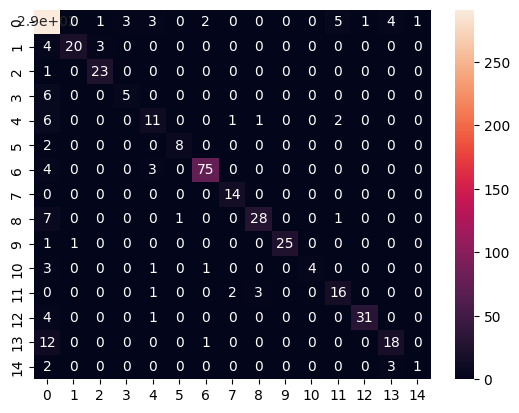

In [ ]:
ax = sns.heatmap(confusion_matrix(y_test, best_model.predict(X_test)), annot = True);

In [146]:
y_filter.value_counts()

AdenoCA      1245
HCC           326
Medullo       146
RCC           144
SCC           123
Melanoma      107
BNHL          107
CLL            95
PiloAstro      89
Endocrine      85
MPN            56
ChRCC          45
GBM            41
Osteosarc      38
TCC            23
Name: count, dtype: int64

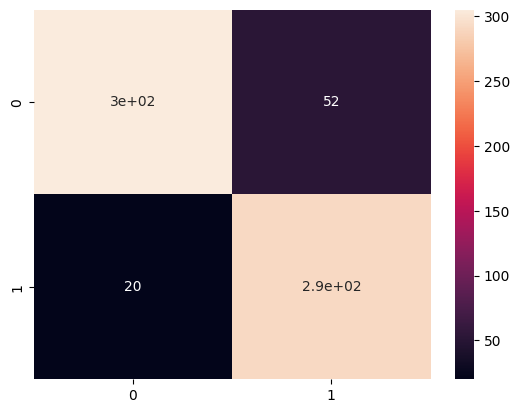

In [147]:
sns.heatmap(confusion_matrix(y_test == "AdenoCA", best_model.predict(X_test) == "AdenoCA"), annot = True);

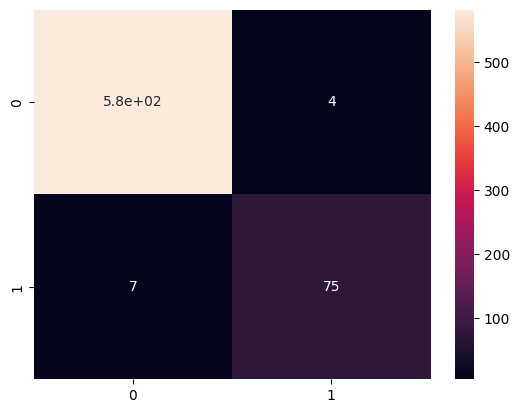

In [148]:
sns.heatmap(confusion_matrix(y_test == "HCC", best_model.predict(X_test) == "HCC"), annot = True);

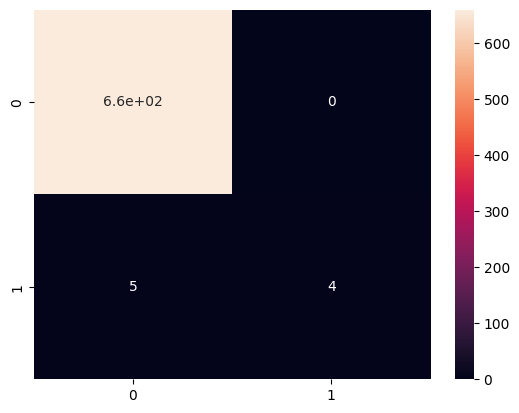

In [149]:
sns.heatmap(confusion_matrix(y_test == "Osteosarc", best_model.predict(X_test) == "Osteosarc"), annot = True);

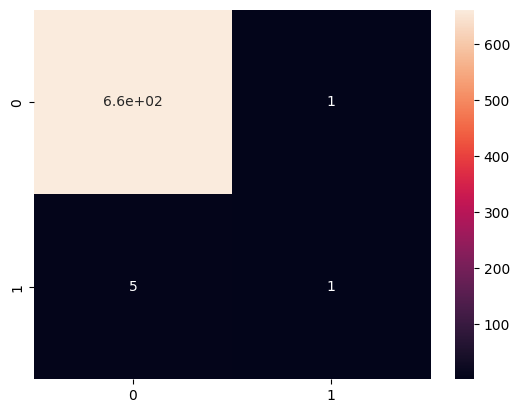

In [150]:
sns.heatmap(confusion_matrix(y_test == "TCC", best_model.predict(X_test) == "TCC"), annot = True);

# Approach with Random Forest Classifier 


In [151]:
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [152]:
random_forest = RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=42)
parameters = {
    "n_estimators": randint(300, 900),
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.5]
}

In [153]:
search = RandomizedSearchCV(
    random_forest, 
    parameters,
    n_iter=40,
    scoring="balanced_accuracy",
    cv=3,
    n_jobs=-1
)

In [154]:
search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....0014255A38EF0>, 'n_estimators': <scipy.stats....0014246861E00>}"
,n_iter,40
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [155]:
best_model_2 = search.best_estimator_
y_pred = best_model_2.predict(X_test)

In [156]:
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Balanced Accuracy: ", balanced_accuracy_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

Accuracy Score:  0.75
Balanced Accuracy:  0.6827067790023342
F1 score:  0.6508783416913422
              precision    recall  f1-score   support

     AdenoCA       0.89      0.74      0.81       311
        BNHL       0.87      0.74      0.80        27
         CLL       0.47      0.92      0.62        24
       ChRCC       0.23      0.64      0.34        11
   Endocrine       0.47      0.38      0.42        21
         GBM       1.00      0.70      0.82        10
         HCC       0.91      0.90      0.91        82
         MPN       0.60      0.64      0.62        14
     Medullo       0.57      0.76      0.65        37
    Melanoma       0.87      0.74      0.80        27
   Osteosarc       0.67      0.44      0.53         9
   PiloAstro       0.55      0.73      0.63        22
         RCC       0.83      0.83      0.83        36
         SCC       0.61      0.74      0.67        31
         TCC       0.29      0.33      0.31         6

    accuracy                           0.75

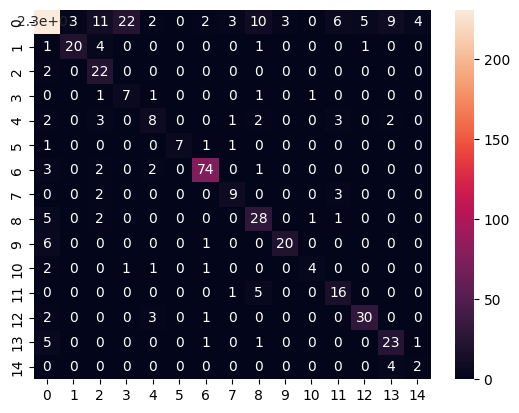

In [157]:
ax = sns.heatmap(confusion_matrix(y_test, best_model_2.predict(X_test)), annot = True);

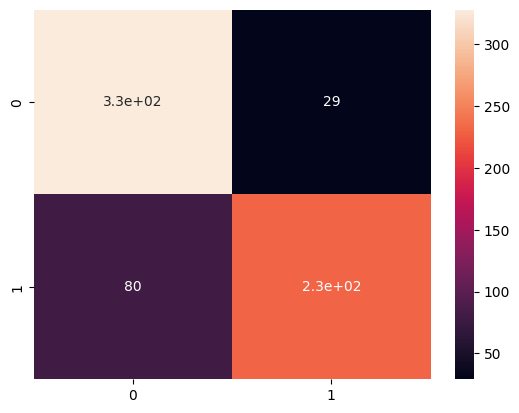

In [158]:
sns.heatmap(confusion_matrix(y_test == "AdenoCA", best_model_2.predict(X_test) == "AdenoCA"), annot = True);

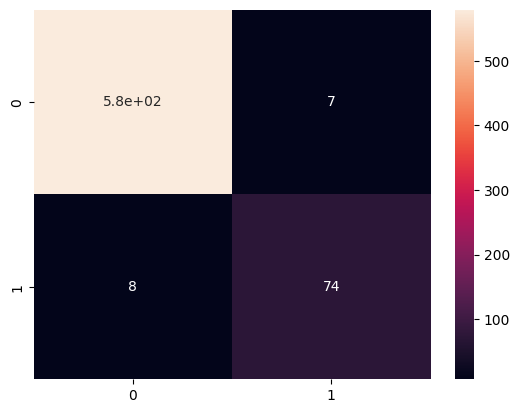

In [159]:
sns.heatmap(confusion_matrix(y_test == "HCC", best_model_2.predict(X_test) == "HCC"), annot = True);

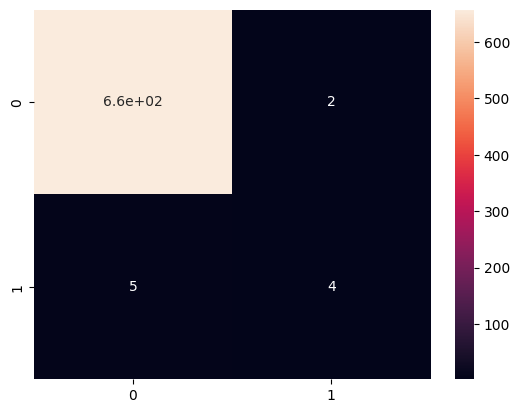

In [160]:
sns.heatmap(confusion_matrix(y_test == "Osteosarc", best_model_2.predict(X_test) == "Osteosarc"), annot = True);

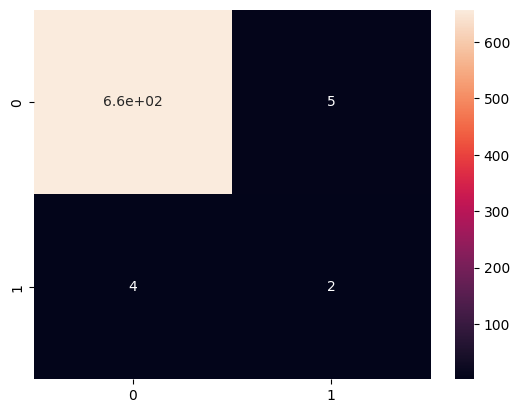

In [161]:
sns.heatmap(confusion_matrix(y_test == "TCC", best_model_2.predict(X_test) == "TCC"), annot = True);

# ExtraTree Classifier Approach 

In [162]:
from sklearn.ensemble import ExtraTreesClassifier


In [163]:
extra_tree = ExtraTreesClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

et_param_dist = {
    "n_estimators": randint(300, 900),
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7]
}

In [164]:
search_2 = RandomizedSearchCV(
    extra_tree,
    et_param_dist,
    n_iter=40,
    scoring="balanced_accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [165]:
search_2.fit(X_train, y_train)

Fitting 3 folds for each of 40 candidates, totalling 120 fits


,estimator,ExtraTreesCla...ndom_state=42)
,param_distributions,"{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....0014277EC7350>, 'n_estimators': <scipy.stats....0014277EC6360>}"
,n_iter,40
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [166]:
best_model_3 = search_2.best_estimator_
y_pred = best_model_3.predict(X_test)

In [167]:
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("Balanced Accuracy: ", balanced_accuracy_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

Accuracy Score:  0.7619760479041916
Balanced Accuracy:  0.7140580436869323
F1 score:  0.6676834120565565
              precision    recall  f1-score   support

     AdenoCA       0.92      0.74      0.82       311
        BNHL       0.76      0.81      0.79        27
         CLL       0.52      0.92      0.67        24
       ChRCC       0.26      0.82      0.40        11
   Endocrine       0.41      0.43      0.42        21
         GBM       1.00      0.70      0.82        10
         HCC       0.91      0.90      0.91        82
         MPN       0.60      0.64      0.62        14
     Medullo       0.59      0.78      0.67        37
    Melanoma       0.88      0.81      0.85        27
   Osteosarc       0.71      0.56      0.62         9
   PiloAstro       0.52      0.68      0.59        22
         RCC       0.94      0.83      0.88        36
         SCC       0.61      0.74      0.67        31
         TCC       0.25      0.33      0.29         6

    accuracy                 

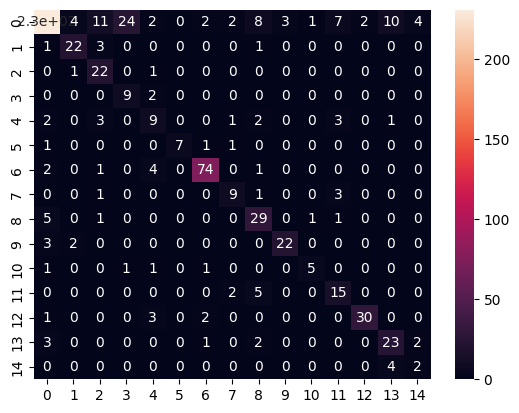

In [168]:
ax = sns.heatmap(confusion_matrix(y_test, best_model_3.predict(X_test)), annot = True);

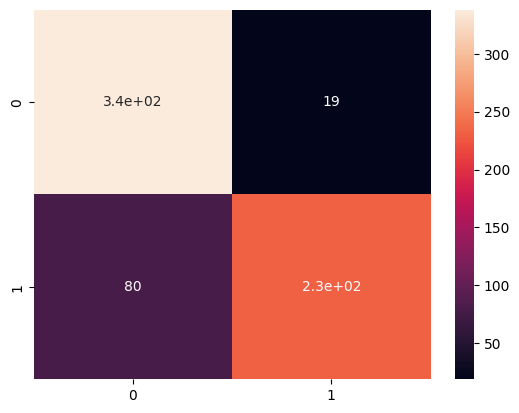

In [169]:
sns.heatmap(confusion_matrix(y_test == "AdenoCA", best_model_3.predict(X_test) == "AdenoCA"), annot = True);

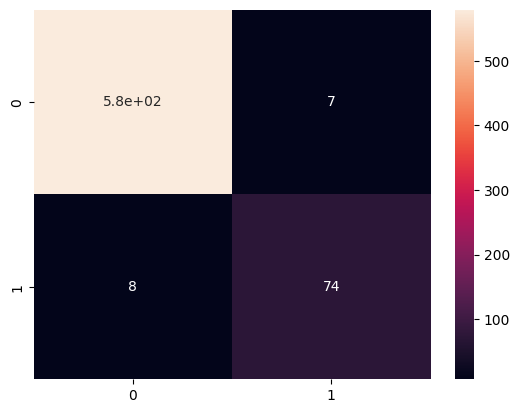

In [170]:
sns.heatmap(confusion_matrix(y_test == "HCC", best_model_3.predict(X_test) == "HCC"), annot = True);

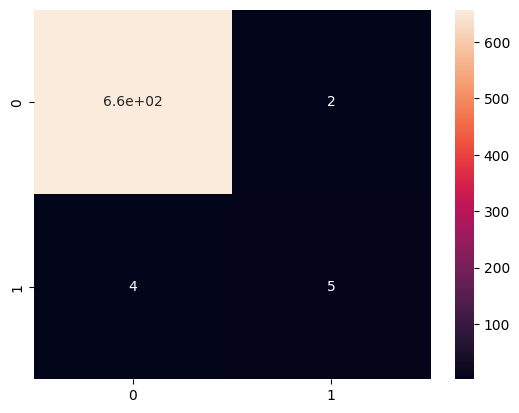

In [171]:
sns.heatmap(confusion_matrix(y_test == "Osteosarc", best_model_3.predict(X_test) == "Osteosarc"), annot = True);

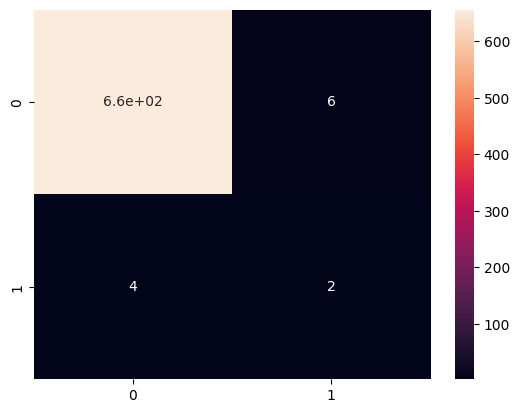

In [172]:
sns.heatmap(confusion_matrix(y_test == "TCC", best_model_3.predict(X_test) == "TCC"), annot = True);